In [2]:
!pip install qiskit --quiet
!pip install pylatexenc --quiet
!pip install qiskit-aer --quiet # Install the missing module

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.7 MB/s eta 0:00:00


In [3]:
from qiskit import *
from qiskit.visualization import plot_histogram
from google.colab import widgets
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual, Button, Layout
import ipywidgets
import pandas as pd
import math
import numpy as np
import random
from IPython.display import clear_output
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit.qasm2 import dumps as qasm2_dumps

In [4]:
# Create a simple function to wrap your quantum program up, send to Quokka, and extract results
import requests # Ensure requests is imported if not already in the notebook
import json # Ensure json is imported if not already in the notebook
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning) # Disable warnings about insecure requests

# default Quokka address (change if you have your own!):
my_quokka = 'quokka1'

# the complete addresss
request_http = 'http://{}.quokkacomputing.com/qsim/qasm'.format(my_quokka)

from qiskit.qasm2 import dumps as qasm2_dumps # Import qasm2_dumps here

def send_to_the_quokka(circuit_qasm):

  #print(circuit_qasm)

  # create data to wrap in JSON object to send to Quokka
  data = {
    'script': circuit_qasm,
    'count': 1
    }

  try:
    result = requests.post(request_http, json=data, verify=False) # send to Quokka and record results
    result.raise_for_status() # Raise an exception for bad status codes
    json_obj = json.loads(result.content) # convert to dictionary

    ## Print the full JSON response for debugging
    #print("Quokka API Response:")
    #print(json.dumps(json_obj, indent=4))

    return ''.join(map(str, json_obj['result']['c'][0])) # convert to a string of binary values

  except requests.exceptions.RequestException as e:
    print(f"Error sending request to Quokka: {e}")
    return None
  except json.JSONDecodeError as e:
    print(f"Error decoding JSON response from Quokka: {e}")
    return None
  except KeyError as e:
    print(f"KeyError: Missing key in Quokka API response: {e}")
    print("Full response:")
    print(json.dumps(json_obj, indent=4)) # Print the response even if KeyError occurs
    return None

The code for the game comprises the two classes below. Edit at your peril. But also, edit if you want to change the rules of the game!

In [1]:
class Board:
    def __init__(self): # Initialize the board
        self.qc = QuantumCircuit(9, 9) # define circuit
        self.function = ''
        self.target = -1
        self.tab = []
        self.winsX = 0
        self.winsO = 0

        # Initialize the board with empty cells
        for idx in range(0, 9):
            self.tab.append({'default':str(idx), 'player':' '})
            #self.qc.reset(idx)
            self.qc.h(idx)
        #self.qc.barrier()

    def make_move(self, cell):
        # Make a move based on the selected function
        if self.function == 'Not': # X gate (NOT operation)
            self.qc.x(cell)
            self.tab[int(cell)]['player'] += 'N - '
        elif self.function == 'O': # rotation toward |0>
            self.qc.ry(math.pi/2, cell)
            self.tab[int(cell)]['player'] += "O - "
        elif self.function == 'X':  # rotation toward |1>
            self.qc.ry(-math.pi/2, cell)
            self.tab[int(cell)]['player'] += "X - "
        elif self.function == 'SWAP' and self.target != cell:
            if self.target == cell:
                self.target = -1
            else:
                self.qc.swap(int(cell), int(self.target)) # swap gate
                self.tab[int(cell)]['player'] += "S - "
                self.tab[int(self.target)]['player'] += "S - "

    def results(self):
        # Display the results of the quantum circuit.
        display(self.qc.draw('mpl'))
        self.qc = QuantumCircuit(9, 9)

    def display(self):
        # Display the current state of the quantum circuit.
        display(self.qc.draw('mpl'))

    def measure(self):
        # Measure the quantum circuit and update the board based on the measurement results.
        self.qc.barrier()
        for i in range(0,9):
            self.qc.measure(i, i)

        # Convert to QASM 2 and send to Quokka
        qasm_code = qasm2_dumps(self.qc)
        #result = send_to_the_quokka(qasm_code)

        # Total win counters
        total_wins_X = 0
        total_wins_O = 0

        n_trials = 10
        results = []
        for idx in range(n_trials):
            results.append(send_to_the_quokka(qasm_code))

        print("Results")
        print(results)

        for trial_num, output in enumerate(results, start=1):
          print(f"\nProcessing result {trial_num}: {output}")

          for i in range(9):
              if output[8 - i] == '0':
                  self.tab[i]['player'] = 'X'  # Cell collapsed to |0⟩
              else:
                  self.tab[i]['player'] = 'O'  # Cell collapsed to |1⟩

          winsX = self.countWinners('X')
          winsO = self.countWinners('O')

          total_wins_X += winsX
          total_wins_O += winsO

          print("Updated Board:")
          for idx in range(9):
              print(f"Cell {idx}: {self.tab[idx]['player']}")

          print(f"X wins (this round): {winsX}, O wins (this round): {winsO}")
          print("-" * 30)

        #Final win summary
        print("Final Summary Across All Trials:")
        print(f"Total X wins: {total_wins_X}")
        print(f"Total O wins: {total_wins_O}")

    def countWinners(self, player): # Count the number of wins for the specified player.
        # Define winning combinations (triplets)
        winners = [(0, 1, 2), # Row 1
                   (3, 4, 5), # Row 2
                   (6, 7, 8), # Row 3
                   (0, 3, 6), # Column 1
                   (1, 4, 7), # Column 2
                   (2, 5, 8), # Column 3
                   (0, 4, 8), # Diagonal \
                   (2, 4, 6)] # Diagonal /
        wins = 0
        """for triplet in winners:
            won = True
            for idx in triplet:
                if self.tab[idx]['player'] != player:
                    won = False
            if won:
                wins += 1  # Increment win count if a winning triplet is found
        return wins"""
        for i in range(len(winners)):
            won = True
            for j in range(len(winners[0])):
                if not self.tab[winners[i][j]]['player'] == player:
                    won = False
            if won:
                wins = wins + 1
        return wins

    def new(self):
        # Reset the board for a new game.
        self.tab.clear()
        for idx in range(0,9):
           self.tab.append({'default':str(idx), 'player':''})
           self.qc.reset(idx)
           self.qc.h(idx)
        self.qc.barrier()

In [5]:
class Game:
    def __init__(self): # Initialize the game
        self.selecting = False
        self.board = Board()
        self.boardbutton_list = []
        for i in range(0,9):
            button = Button(description=str(i))
            button.on_click(self.handle_game)
            self.boardbutton_list.append(button)

        self.funcbutton_list = []
        self.newButton('Measure') # create measure button
        self.newButton('Not') # create Not button
        self.newButton('O') # create O button
        self.newButton('X') # create X button
        self.newButton('SWAP') # create SWAP button
        self.printmenu()
        self.printBoard()

    def newButton(self, name):
        # Create a new function button.
        function = Button(description=name, layout=Layout(width='86px', height='30px'))
        function.on_click(self.handle_game)
        self.funcbutton_list.append(function)

    def handle_game(self, b):
        # Handle game events based on button clicks.
        try:
            if b.description == 'Measure':
                clear_output()
                self.replay()
                self.board.measure() # Measure the quantum circuit
                self.scoreboard()    # Update the scoreboard
                self.printBoard()    # Display the board
                self.board.results() # Show the results

            if b.description == 'Replay':
                clear_output()
                self.board.new() # Reset the board for a new game
                self.printmenu()
                self.printBoard()

            if int(b.description) >= 0:
                if self.selecting:
                    self.board.target = int(b.description) # Set the target for SWAP
                else:
                    clear_output()
                    self.printmenu()
                    self.board.make_move(int(b.description)) # Make a player move
                    self.printBoard()
                    self.board.display()
            self.selecting = False
        except ValueError:
            self.board.function = b.description # Set the selected function
            self.selecting = False
            if self.board.function == 'SWAP':
                self.selecting = True     # Allow target selection for SWAP

    def printmenu(self): # Display the function menu for the game.
        grid = widgets.Grid(1, 5)
        for (row, col) in grid:
            display(self.funcbutton_list[col])

    def scoreboard(self): # Display the current score of the game.
        print("X wins: " + str(self.board.winsX) + "    O wins: " + str(self.board.winsO))

    def replay(self): # Provide a button to replay the game.
        rep = Button(description="Replay")
        rep.on_click(self.handle_game)
        display(rep)

    def printBoard(self): # Print the current state of the board.
        grid = widgets.Grid(1, int(np.sqrt(9)), header_row=True, header_column=True)
        for row in range(int(np.sqrt(9))):
              for (useless, col) in grid:
                  print("\n"+self.board.tab[col + row * int(np.sqrt(9))]['player']+"\n")
                  display(self.boardbutton_list[col + row * int(np.sqrt(9))])

In this iteration, we'll play the game on the qiskit simulator.

# The game!

To make a move, click one of the 5 options above the board and then click the location where you want to make that move. To play "SWAP," you need to click two board locations.

Each move adds a gate to the game circuit. They do the following:


*   **Measure** ends the round and execute the game circuit on the quantum device. The win conditions will be counted and displayed.
*   **Not** flips an "owned" tile to the other player. If the tile is not currently owned, this does nothing.
*   **O** turns the intial tile toward a tile owned by "O."
*   **X** turns the intial tile toward a tile owned by "X."
*   **SWAP** swaps the location of two tiles.

As you play, you will see the game circuit and the board. The board shows the sequence of moves, but is not 100% accurate. The game circuit is true state of the game.

Button(description='Replay', style=ButtonStyle())

Results
['100000101', '110100101', '000001101', '010001101', '110100101', '100100101', '000111101', '010010101', '110010101', '100010101']

Processing result 1: 100000101
Updated Board:
Cell 0: O
Cell 1: X
Cell 2: O
Cell 3: X
Cell 4: X
Cell 5: X
Cell 6: X
Cell 7: X
Cell 8: O
X wins (this round): 2, O wins (this round): 0
------------------------------

Processing result 2: 110100101
Updated Board:
Cell 0: O
Cell 1: X
Cell 2: O
Cell 3: X
Cell 4: X
Cell 5: O
Cell 6: X
Cell 7: O
Cell 8: O
X wins (this round): 0, O wins (this round): 1
------------------------------

Processing result 3: 000001101
Updated Board:
Cell 0: O
Cell 1: X
Cell 2: O
Cell 3: O
Cell 4: X
Cell 5: X
Cell 6: X
Cell 7: X
Cell 8: X
X wins (this round): 2, O wins (this round): 0
------------------------------

Processing result 4: 010001101
Updated Board:
Cell 0: O
Cell 1: X
Cell 2: O
Cell 3: O
Cell 4: X
Cell 5: X
Cell 6: X
Cell 7: O
Cell 8: X
X wins (this round): 0, O wins (this round): 0
------------------------------



,,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


O



Button(description='8', style=ButtonStyle())

<IPython.core.display.Javascript object>

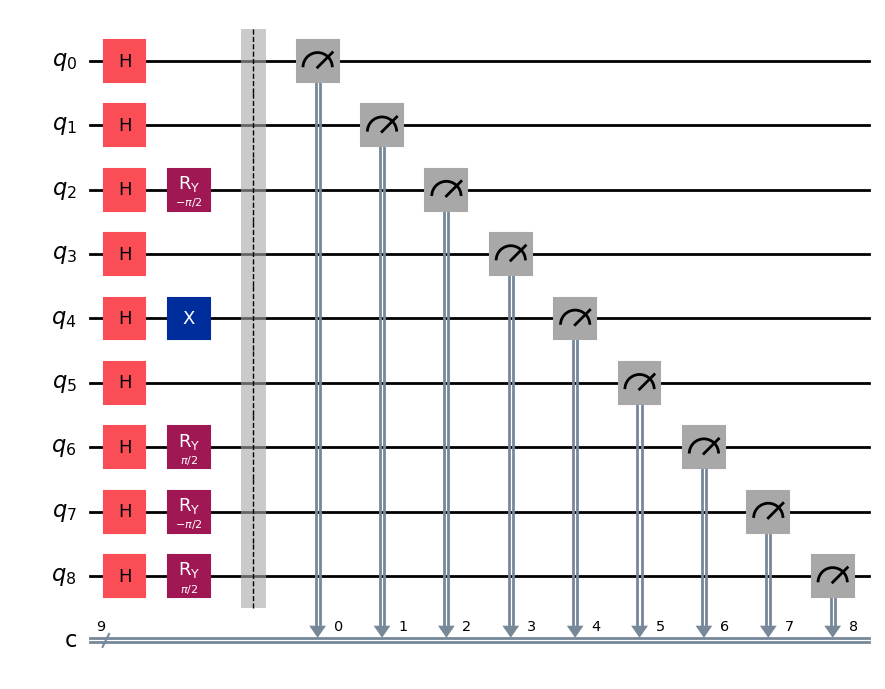

In [6]:
game = Game()

In [41]:
pip show pylatexenc


Name: pylatexenc
Version: 2.10
Summary: Simple LaTeX parser providing latex-to-unicode and unicode-to-latex conversion
Home-page: https://github.com/phfaist/pylatexenc
Author: Philippe Faist
Author-email: philippe.faist@bluewin.ch
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: 
Required-by: 
